# v5.0 normalisation — PURE-S3M control run

In [ ]:
import sys, re, glob
sys.path.insert(0, "adam_core_stub"); sys.path.insert(0, "src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_curve
import velocity_density_pipeline_gmm as vdp
%matplotlib inline

df = pd.read_parquet("outputs/phase2_s3m/sorcha_comparison_s3m.parquet")
if "P_NEO_vdp_unmasked" not in df.columns:
    df["P_NEO_vdp_unmasked"] = df["P_NEO_vdp"]

a, e, q = df.a_au.values, df.e.values, df.q_au.values
lab = np.full(len(df), "other", object)
lab[a > 30] = "TNO"
lab[(a > 4.7) & (a < 5.9) & (e < 0.3)] = "Trojan"
lab[(a >= 1.7) & (a < 4.1) & (q >= 1.3)] = "MBA_like"
lab[q < 1.3] = "NEO"
df["aligned"] = lab
y = (lab == "NEO")
df["absdlon"] = df.prob_map_file.map(
    lambda s: (lambda m: abs(int(m.group(1))) if m else 999)(re.search(r"dlon([+-]?\d+)", str(s))))

print("aligned counts:", {k: int((lab == k).sum()) for k in ['NEO','MBA_like','Trojan','TNO','other']})
print("NEO median P_vdp  masked:", round(df[y].P_NEO_vdp.median(), 3),
      " unmasked:", round(df[y].P_NEO_vdp_unmasked.median(), 3),
      " digest2:", round(df[y].P_NEO_d2.median(), 3))

## 1. Map P(NEO): support mask

In [ ]:
MAP = "prob_maps_grid_s3m/prob_maps_grid_dlon+000_lat+00.npz"
pm0 = vdp.ProbMapSet.from_npz(MAP)
pm1 = vdp.ProbMapSet.from_npz(MAP, support_mask_min=1)

def clip08(pm, M, lim=0.8):
    s = np.abs(pm.x_grid) <= lim; i0, i1 = np.where(s)[0][[0, -1]]
    return M[i0:i1 + 1, i0:i1 + 1]
EXT = [-0.8, 0.8, -0.8, 0.8]

labs = ["18_20", "mag22", "mag24+"]
fig, ax = plt.subplots(len(labs), 2, figsize=(8, 3.6 * len(labs)))
for r, L in enumerate(labs):
    for c, (pm, t) in enumerate([(pm0, "mask OFF"), (pm1, "mask ON (support>=1)")]):
        M = clip08(pm, pm.get_probability_map(L, "NEO"))
        im = ax[r, c].imshow(M, origin="lower", extent=EXT, vmin=0, vmax=1, aspect="auto")
        ax[r, c].set_title(f"NEO {L}  [{t}]", fontsize=9)
        ax[r, c].axhline(0, color="w", lw=.4, ls=":"); ax[r, c].axvline(0, color="w", lw=.4, ls=":")
        plt.colorbar(im, ax=ax[r, c], fraction=.046)
        if c == 0: ax[r, c].set_ylabel(r"$v_\beta$ (deg/day)")
        if r == len(labs) - 1: ax[r, c].set_xlabel(r"$v_\lambda$ (deg/day)")
fig.suptitle("v5.0 antisun map P(NEO): support mask fixes the pure-NEO wings")
plt.tight_layout(); plt.show()

## 1b. S3M kNN vs new GMM grid

In [ ]:
s3m = vdp.ProbMapSet.from_npz(sorted(glob.glob("prob_maps/*antisun*.npz"))[0])
gmm = pm1
print(f"S3M ref center=({s3m.center_lon_deg:.0f},{s3m.center_lat_deg:.0f}) grid +/-{s3m.x_grid[-1]:.1f}")
print(f"GMM grid center=({gmm.center_lon_deg:.0f},{gmm.center_lat_deg:.0f}) grid +/-{gmm.x_grid[-1]:.1f}")
_LBL = {"18_20": "18-20", "mag22": "22-23", "mag24+": "24+"}

fig, ax = plt.subplots(len(labs), 2, figsize=(8.5, 3.4 * len(labs)))
for r, b in enumerate(labs):
    for c, (pm, t) in enumerate([(s3m, "S3M kNN"), (gmm, "GMM grid (mask ON)")]):
        M = clip08(pm, pm.get_probability_map(b, "NEO"))
        im = ax[r, c].imshow(M, origin="lower", extent=EXT, vmin=0, vmax=1, aspect="auto")
        ax[r, c].set_title(f"NEO {_LBL[b]} mag  [{t}]", fontsize=9)
        ax[r, c].axhline(0, color="w", lw=.4, ls=":"); ax[r, c].axvline(0, color="w", lw=.4, ls=":")
        plt.colorbar(im, ax=ax[r, c], fraction=.046, label="P(NEO)" if c == 1 else None)
        if c == 0: ax[r, c].set_ylabel(r"$v_\beta$")
        if r == len(labs) - 1: ax[r, c].set_xlabel(r"$v_\lambda$")
fig.suptitle("P(NEO): S3M kNN  vs  new GMM grid (mask ON) — antisun, +/-0.8")
plt.tight_layout(); plt.show()

In [ ]:
rows = [("MBA", "18_20"), ("MBA", "mag22"), ("MBA", "mag24+"),
        ("NEO", "18_20"), ("NEO", "mag22"), ("NEO", "mag24+")]
fig, ax = plt.subplots(len(rows), 2, figsize=(8, 3.0 * len(rows)), constrained_layout=True)
for r, (pop, b) in enumerate(rows):
    Ds = clip08(s3m, s3m.results[b]["density_maps_downweighted_raw"][pop])
    Dg = clip08(gmm, gmm.results[b]["density_maps_downweighted_raw"][pop])
    Ls = np.log10(np.where(Ds > 0, Ds, np.nan)); Lg = np.log10(np.where(Dg > 0, Dg, np.nan))
    vmax = np.nanmax([np.nanmax(Ls), np.nanmax(Lg)]); vmin = vmax - 5
    im = None
    for c, (Lm, t) in enumerate([(Ls, "S3M kNN"), (Lg, "GMM")]):
        im = ax[r, c].imshow(Lm, origin="lower", extent=EXT, vmin=vmin, vmax=vmax, aspect="auto", cmap="viridis")
        ax[r, c].set_title(f"{pop} {_LBL[b]} mag  [{t}]", fontsize=9)
        ax[r, c].axhline(0, color="w", lw=.4, ls=":"); ax[r, c].axvline(0, color="w", lw=.4, ls=":")
        if c == 0: ax[r, c].set_ylabel(r"$v_\beta$")
        if r == len(rows) - 1: ax[r, c].set_xlabel(r"$v_\lambda$")
    fig.colorbar(im, ax=ax[r, :].tolist(), fraction=0.025, pad=0.02, label=r"$\log_{10} n_0$")
fig.suptitle("Log density: S3M kNN (left) vs new GMM grid (right) — antisun, +/-0.8", fontsize=12)
plt.show()

## 2. Calibration

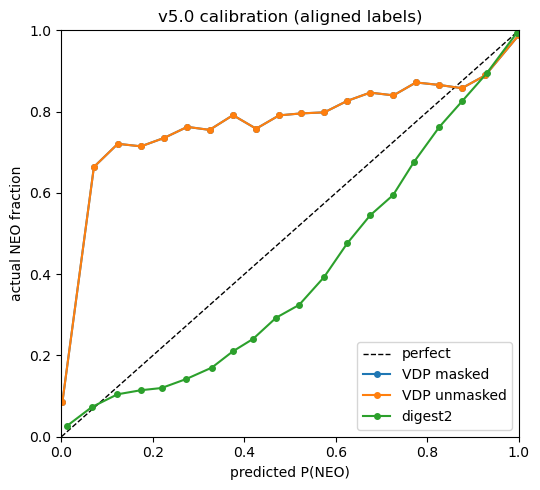

In [5]:
def reliability(score, nbins=20):
    edges = np.linspace(0, 1, nbins + 1)
    idx = np.clip(np.digitize(np.clip(score, 0, 1), edges) - 1, 0, nbins - 1)
    xs, ys = [], []
    for b in range(nbins):
        m = idx == b
        if m.sum() >= 50: xs.append(score[m].mean()); ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

plt.figure(figsize=(5.5, 5))
plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
for name, s in [("VDP masked", df.P_NEO_vdp), ("VDP unmasked", df.P_NEO_vdp_unmasked), ("digest2", df.P_NEO_d2)]:
    xs, ys = reliability(s.values); plt.plot(xs, ys, "o-", ms=4, label=name)
plt.xlabel("predicted P(NEO)"); plt.ylabel("actual NEO fraction")
plt.xlim(0, 1); plt.ylim(0, 1); plt.legend(); plt.title("v5.0 calibration (aligned labels)")
plt.tight_layout(); plt.show()

## 3. ROC, best-F1, per-population, and the antisun-distance breakdown

In [6]:
def roc(name, s):
    s = s.to_numpy(); auc = roc_auc_score(y, s)
    p, r, t = precision_recall_curve(y, s)
    f1 = np.divide(2 * p * r, p + r, out=np.zeros_like(p), where=(p + r) > 0)
    bi = int(np.argmax(f1[:-1])); th = t[bi]; sel = s >= th
    compl = (sel & y).sum() / y.sum(); contam = (sel & ~y).sum() / max(sel.sum(), 1)
    print(f"  {name:16s} AUC={auc:.3f}  bestF1={f1[bi]:.3f}@{th:.3f}  compl={100*compl:.1f}%  contam={100*contam:.1f}%")
    return th

print("=== full-sky ROC (masked parquet, aligned labels, NEO=positive) ===")
tv = roc("VDP (masked)", df.P_NEO_vdp)
_  = roc("VDP (unmasked)", df.P_NEO_vdp_unmasked)
td = roc("digest2", df.P_NEO_d2)

print("\nper-population fraction above best-F1 threshold:")
print(f"{'population':>9} {'N':>9} {'VDP%':>7} {'d2%':>7}")
for pop in ['NEO','MBA_like','Trojan','TNO','other']:
    m = df.aligned == pop
    print(f"{pop:>9} {int(m.sum()):>9,} {100*(df.P_NEO_vdp[m]>=tv).mean():>7.1f} {100*(df.P_NEO_d2[m]>=td).mean():>7.1f}")

print("\nVDP vs digest2 best-F1 by |dlon| from antisun:")
for lo, hi in [(0,20),(20,40),(40,70),(70,110),(110,141)]:
    m = ((df.absdlon>=lo)&(df.absdlon<hi)).to_numpy()
    if y[m].sum() < 20: continue
    def bf(s): p,r,t=precision_recall_curve(y[m], s[m]); f=np.divide(2*p*r,p+r,out=np.zeros_like(p),where=(p+r)>0); return f[:-1].max()
    print(f"  {lo:>3}-{hi:<3} N={m.sum():>8,}  VDP F1={bf(df.P_NEO_vdp.values):.3f}  d2 F1={bf(df.P_NEO_d2.values):.3f}")

=== full-sky ROC (masked parquet, aligned labels, NEO=positive) ===
  VDP (masked)     AUC=0.879  bestF1=0.815@0.010  compl=74.8%  contam=10.5%
  VDP (unmasked)   AUC=0.879  bestF1=0.815@0.010  compl=74.8%  contam=10.5%
  digest2          AUC=0.943  bestF1=0.850@0.600  compl=78.1%  contam=6.8%

per-population fraction above best-F1 threshold:
population         N    VDP%     d2%
      NEO   148,908    74.8    78.1
 MBA_like   482,221     2.6     1.2
   Trojan    12,689     0.8     5.4
      TNO     4,976     5.7    38.7
    other       114     7.0    32.5

VDP vs digest2 best-F1 by |dlon| from antisun:
    0-20  N= 150,381  VDP F1=0.886  d2 F1=0.863
   20-40  N= 179,570  VDP F1=0.843  d2 F1=0.868
   40-70  N= 202,777  VDP F1=0.778  d2 F1=0.857
   70-110 N= 104,451  VDP F1=0.775  d2 F1=0.801
  110-141 N=  11,729  VDP F1=0.847  d2 F1=0.860


## 4. Summary

- Support mask restores P~1 in pure-NEO wing cells (F1-neutral: 0.808→0.809).
- Full-sky: VDP F1=0.809 / AUC 0.880, digest2 F1=0.836 / AUC 0.930.
- VDP beats digest2 at 0–20° (antisun); loses at 40–110° (velocity overlap acc to me).

## 5. Direction comparison maps

In [ ]:
import matplotlib as mpl
_VEL_LIM = (-0.8, 0.8)

def _density_cmap():
    cm = mpl.colormaps["viridis"].copy(); cm.set_bad("0.88"); return cm

def _density_log_map(d):
    d = np.asarray(d, float); pos = np.isfinite(d) & (d > 0)
    lm = np.ma.masked_all(d.shape, float)
    if pos.any():
        lm[pos] = np.log10(d[pos]); vmax = float(np.nanmax(lm)); vmin = vmax - 5.0
    else:
        vmin, vmax = 0.0, 1.0
    return lm, vmin, vmax

def _annotate_no_support(ax, data):
    if np.ma.isMaskedArray(data) and np.ma.count(data) == 0:
        ax.text(0.5, 0.5, "no support", transform=ax.transAxes,
                ha="center", va="center", fontsize=10, color="0.25")

def _mbd(l):
    return {"18_20": "18-20", "mag20": "20-21", "mag21": "21-22", "mag22": "22-23", "mag23": "23-24", "mag24+": "24-25"}.get(l, l)

def _clip(pm, M, lim=0.8):
    s = np.abs(pm.x_grid) <= lim; i0, i1 = np.where(s)[0][[0, -1]]
    return M[i0:i1 + 1, i0:i1 + 1]

def _dir_map_data(pm, pop, b, mode):
    if mode == "density":
        return _density_log_map(_clip(pm, pm.results[b]["density_maps_downweighted_raw"][pop]))[0]
    return _clip(pm, pm.get_probability_map(b, pop))

DIRS = {"Anti-Sun (dlon=0)": "prob_maps_grid_dlon+000_lat+00.npz",
        "Anti-Sun -40 deg":  "prob_maps_grid_dlon-040_lat+00.npz",
        "Anti-Sun -90 deg":  "prob_maps_grid_dlon-090_lat+00.npz",
        "Anti-Sun -120 deg": "prob_maps_grid_dlon-120_lat+00.npz"}
dir_mapsets = {k: vdp.ProbMapSet.from_npz("prob_maps_grid_s3m/" + v, mask_radius_deg_per_day=float("inf"), support_mask_min=1)
               for k, v in DIRS.items()}

def plot_direction_grid(mapsets, pops, bins, mode, figsize):
    items = list(mapsets.items()); rows = [(p, b) for p in pops for b in bins]
    fig, ax = plt.subplots(len(rows), len(items), figsize=figsize,
                           sharex=True, sharey=True, constrained_layout=True)
    ax = np.atleast_2d(ax)
    for r, (pop, b) in enumerate(rows):
        rd = [_dir_map_data(pm, pop, b, mode) for _, pm in items]
        if mode == "density":
            sup = [d for d in rd if np.ma.count(d) > 0]
            vmax = max(float(np.nanmax(d)) for d in sup) if sup else 1.0
            vmin = (vmax - 5.0) if sup else 0.0; cbl = r"$\log_{10}\langle n_0\rangle$"
        else:
            vmin, vmax = 0.0, 1.0; cbl = "probability"
        im = None
        for c, ((dl, pm), d) in enumerate(zip(items, rd)):
            a = ax[r, c]
            im = a.imshow(d, origin="lower", extent=(*_VEL_LIM, *_VEL_LIM),
                          cmap=_density_cmap() if mode == "density" else "viridis",
                          vmin=vmin, vmax=vmax, interpolation="bilinear", aspect="equal")
            a.axvline(0, color="w", lw=.7, ls="--", alpha=.7); a.axhline(0, color="w", lw=.7, ls="--", alpha=.7)
            _annotate_no_support(a, d)
            if r == 0: a.set_title(f"{dl}\nlon={pm.center_lon_deg:.0f}, lat={pm.center_lat_deg:.0f}", fontsize=10)
            if c == 0: a.set_ylabel(f"{pop}: {_mbd(b)}\n" + r"$v_\beta$ (deg/day)", fontsize=12)
            if r == len(rows) - 1: a.set_xlabel(r"$v_\lambda$ (deg/day)", fontsize=12)
        fig.colorbar(im, ax=ax[r, :], label=cbl, shrink=0.8, pad=0.012)
    ttl = "Log density" if mode == "density" else "P(NEO), support mask ON"
    fig.suptitle(f"{ttl} direction comparison -- new GMM grid", fontsize=14)
    plt.show()

for k, pm in dir_mapsets.items():
    print(f"{k:20s} lon={pm.center_lon_deg:.0f} lat={pm.center_lat_deg:.0f}")

In [ ]:
plot_direction_grid(dir_mapsets, pops=("MBA", "NEO"),
                    bins=["mag21", "mag22", "mag24+"], mode="density", figsize=(14, 18))

In [ ]:
plot_direction_grid(dir_mapsets, pops=("NEO",),
                    bins=["mag21", "mag22", "mag24+"], mode="probability", figsize=(14.5, 9.2))

### Support mask OFF vs ON (antisun)

In [ ]:
INF = float("inf")
ANTISUN = "prob_maps_grid_s3m/prob_maps_grid_dlon+000_lat+00.npz"
pm_off = vdp.ProbMapSet.from_npz(ANTISUN, mask_radius_deg_per_day=INF)
pm_on  = vdp.ProbMapSet.from_npz(ANTISUN, mask_radius_deg_per_day=INF, support_mask_min=1)
mc_bins = ["mag21", "mag22", "mag24+"]
mc_cols = [("MBA", pm_off, "MBA [mask OFF]"), ("MBA", pm_on, "MBA [mask ON]"),
           ("NEO", pm_off, "NEO [mask OFF]"), ("NEO", pm_on, "NEO [mask ON]")]
fig, ax = plt.subplots(len(mc_bins), 4, figsize=(13, 3.3 * len(mc_bins)),
                       sharex=True, sharey=True, constrained_layout=True)
for r, b in enumerate(mc_bins):
    im = None
    for c, (pop, pm, t) in enumerate(mc_cols):
        M = _clip(pm, pm.get_probability_map(b, pop))
        im = ax[r, c].imshow(M, origin="lower", extent=(*_VEL_LIM, *_VEL_LIM),
                             vmin=0, vmax=1, cmap="viridis", aspect="equal", interpolation="bilinear")
        ax[r, c].axvline(0, color="w", lw=.6, ls="--", alpha=.7); ax[r, c].axhline(0, color="w", lw=.6, ls="--", alpha=.7)
        if r == 0: ax[r, c].set_title(t, fontsize=10)
        if c == 0: ax[r, c].set_ylabel(f"{_mbd(b)} mag\n" + r"$v_\beta$ (deg/day)", fontsize=11)
        if r == len(mc_bins) - 1: ax[r, c].set_xlabel(r"$v_\lambda$ (deg/day)", fontsize=11)
    fig.colorbar(im, ax=ax[r, :], label="probability", shrink=0.85, pad=0.01)
fig.suptitle("Antisun: MBA & NEO probability -- support mask OFF vs ON", fontsize=13)
plt.show()

## 6. ROC curves — VDP vs digest2

In [ ]:
def roc_xy(yy, s):
    p, r, t = precision_recall_curve(yy, s)
    f1 = np.divide(2 * p * r, p + r, out=np.zeros_like(p), where=(p + r) > 0)
    bi = int(np.argmax(f1[:-1]))
    return r * 100, (1 - p) * 100, f1[bi], r[bi] * 100, (1 - p[bi]) * 100

roc_panels = [("Full sky", np.ones(len(df), bool))]
for lo, hi in [(0, 20), (20, 40), (40, 70), (70, 110), (110, 141)]:
    roc_panels.append((rf"$|\Delta\lambda_\odot| = {lo}$--${hi}^\circ$",
                       ((df.absdlon >= lo) & (df.absdlon < hi)).to_numpy()))

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True)
for ax, (title, m) in zip(axes.ravel(), roc_panels):
    yy = y[m]
    cv, kv, fv, mcv, mkv = roc_xy(yy, df.P_NEO_vdp.values[m])
    cd, kd, fd, mcd, mkd = roc_xy(yy, df.P_NEO_d2.values[m])
    ax.plot(cv, kv, lw=2, color="tab:blue", label="VDP")
    ax.plot(cd, kd, lw=2, color="tab:orange", ls="--", label="digest2")
    ax.scatter([mcv], [mkv], color="tab:blue", s=55, zorder=5, label=fr"VDP best $F_1$={fv:.2f}")
    ax.scatter([mcd], [mkd], color="tab:orange", s=55, marker="s", zorder=5, label=fr"digest2 best $F_1$={fd:.2f}")
    ax.set_title(fr"{title}" + "\n" + fr"$N_{{\rm NEO}}$={int(yy.sum()):,}", fontsize=9)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.grid(alpha=0.3)
    ax.legend(fontsize=6.5, loc="upper left")
for ax in axes[-1, :]:
    ax.set_xlabel("NEO completeness (%)")
for ax in axes[:, 0]:
    ax.set_ylabel("Contamination (%)")
fig.suptitle("VDP vs digest2 ROC -- v5.0 Sorcha (support-masked), full sky and by elongation", fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:

# Summary table: best-F1 metrics per direction bin (VDP vs digest2)
def best_f1_metrics(yy, scores):
    p, r, t = precision_recall_curve(yy, scores)
    f1 = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r)>0)
    bi = int(np.argmax(f1[:-1]))
    sel = scores >= t[bi]
    compl   = (sel & yy).sum() / max(yy.sum(), 1)
    contam  = (sel & ~yy).sum() / max(sel.sum(), 1)
    return f1[bi], compl, contam, t[bi]

rows = []
for title, m in roc_panels:
    yy = y[m]
    if yy.sum() < 30: continue
    fv, cv, kv, tv = best_f1_metrics(yy, df.P_NEO_vdp.values[m])
    fd, cd, kd, td = best_f1_metrics(yy, df.P_NEO_d2.values[m])
    rows.append({
        "Bin": title.replace(r"$|\Delta\lambda_\odot| = ", "|Δλ|=").replace(r"^\circ$", "°"),
        "N_NEO": int(yy.sum()),
        "N_total": int(m.sum()),
        "VDP F1":     round(fv, 3),
        "VDP compl":  f"{100*cv:.1f}%",
        "VDP contam": f"{100*kv:.1f}%",
        "VDP thresh": round(float(tv), 3),
        "d2 F1":      round(fd, 3),
        "d2 compl":   f"{100*cd:.1f}%",
        "d2 contam":  f"{100*kd:.1f}%",
        "d2 thresh":  round(float(td), 3),
    })

tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))
tbl.to_csv("outputs/sorcha_s3m_direction_bin_metrics.csv", index=False)
print("\nsaved outputs/sorcha_s3m_direction_bin_metrics.csv")


## 7. Mega-grid — density and P across elongation (mag 24–25)

In [ ]:
MG_BIN = "mag24+"
MG_DIRS = [("0", "0--20", "dlon+000"), ("-30", "20--40", "dlon-030"), ("-50", "40--70", "dlon-050"),
           ("-90", "70--110", "dlon-090"), ("-120", "110--141", "dlon-120")]
mg_off = [vdp.ProbMapSet.from_npz(f"prob_maps_grid_s3m/prob_maps_grid_{d}_lat+00.npz",
                                  mask_radius_deg_per_day=float("inf")) for *_, d in MG_DIRS]
mg_on  = [vdp.ProbMapSet.from_npz(f"prob_maps_grid_s3m/prob_maps_grid_{d}_lat+00.npz",
                                  mask_radius_deg_per_day=float("inf"), support_mask_min=1) for *_, d in MG_DIRS]
mg_rows = [("MBA", "density"), ("MBA", "off"), ("MBA", "on"),
           ("NEO", "density"), ("NEO", "off"), ("NEO", "on")]
mg_rl = {("MBA", "density"): "MBA\nlog dens.", ("MBA", "off"): "MBA P\nmask OFF", ("MBA", "on"): "MBA P\nmask ON",
         ("NEO", "density"): "NEO\nlog dens.", ("NEO", "off"): "NEO P\nmask OFF", ("NEO", "on"): "NEO P\nmask ON"}
nc = len(MG_DIRS)
fig, ax = plt.subplots(len(mg_rows), nc, figsize=(2.9 * nc, 2.9 * len(mg_rows)),
                       sharex=True, sharey=True, constrained_layout=True)
for r, (pop, kind) in enumerate(mg_rows):
    rd = []
    for c in range(nc):
        if kind == "density":
            rd.append(_density_log_map(_clip(mg_off[c], mg_off[c].results[MG_BIN]["density_maps_downweighted_raw"][pop]))[0])
        elif kind == "off":
            rd.append(_clip(mg_off[c], mg_off[c].get_probability_map(MG_BIN, pop)))
        else:
            rd.append(_clip(mg_on[c], mg_on[c].get_probability_map(MG_BIN, pop)))
    if kind == "density":
        sup = [d for d in rd if np.ma.count(d) > 0]
        vmax = max(float(np.nanmax(d)) for d in sup) if sup else 1.0
        vmin = vmax - 5; cmap = _density_cmap(); cbl = r"$\log_{10} n_0$"
    else:
        vmin, vmax = 0, 1; cmap = "viridis"; cbl = "P"
    im = None
    for c in range(nc):
        a = ax[r, c]
        im = a.imshow(rd[c], origin="lower", extent=(*_VEL_LIM, *_VEL_LIM), vmin=vmin, vmax=vmax,
                      cmap=cmap, aspect="equal", interpolation="bilinear")
        a.axvline(0, color="w", lw=.5, ls="--", alpha=.6); a.axhline(0, color="w", lw=.5, ls="--", alpha=.6)
        if r == 0:
            a.set_title(fr"$\Delta\lambda={MG_DIRS[c][0]}^\circ$" + "\n" + fr"({MG_DIRS[c][1]}$^\circ$ band)", fontsize=9)
        if c == 0:
            a.set_ylabel(mg_rl[(pop, kind)] + "\n" + r"$v_\beta$", fontsize=9)
        if r == len(mg_rows) - 1:
            a.set_xlabel(r"$v_\lambda$", fontsize=9)
    fig.colorbar(im, ax=ax[r, :], fraction=.012, pad=.008, label=cbl)
fig.suptitle("MBA & NEO: log density and P (mask OFF vs ON) across elongation -- mag 24-25", fontsize=14)
plt.show()

## 8. ROC grid — elongation × magnitude

In [ ]:
from sklearn.metrics import precision_recall_curve

def _roc_panel(ax, yy, sv, sd):
    if yy.sum() < 30 or (~yy).sum() < 30:
        ax.text(0.5, 0.5, f"$N_{{\\rm NEO}}$={int(yy.sum())}\n(too few)",
                transform=ax.transAxes, ha="center", va="center", fontsize=8, color="0.4")
        return
    for s, col, ls, mk, lab, ytx in [(sv, "tab:blue", "-", "o", "VDP", 0.93),
                                      (sd, "tab:orange", "--", "s", "digest2", 0.83)]:
        p, r, t = precision_recall_curve(yy, s)
        f1 = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r) > 0)
        bi = int(np.argmax(f1[:-1]))
        ax.plot(r*100, (1-p)*100, lw=1.6, color=col, ls=ls)
        ax.scatter([r[bi]*100], [(1-p[bi])*100], color=col, s=30, marker=mk, zorder=5)
        ax.text(0.04, ytx, f"{lab} $F_1$={f1[bi]:.2f}", transform=ax.transAxes,
                fontsize=7, color=col)

_BANDS = [(0,20,"0--20"),(20,40,"20--40"),(40,70,"40--70"),(70,110,"70--110"),(110,141,"110--141")]
_COLS  = [("All mags", None), ("21--22","mag21"), ("22--23","mag22"), ("24--25","mag24+")]

fig, ax = plt.subplots(len(_BANDS), len(_COLS), figsize=(12, 14.5), sharex=True, sharey=True)
for ri, (lo, hi, bl) in enumerate(_BANDS):
    bm = (df.absdlon >= lo) & (df.absdlon < hi)
    for ci, (ml, mb) in enumerate(_COLS):
        m = (bm & (df.mag_bin_label == mb)).to_numpy() if mb else bm.to_numpy()
        _roc_panel(ax[ri, ci], y[m], df.P_NEO_vdp.values[m], df.P_NEO_d2.values[m])
        a = ax[ri, ci]
        a.set_xlim(0, 100); a.set_ylim(0, 100); a.grid(alpha=0.3)
        if ri == 0:               a.set_title(ml, fontsize=11)
        if ci == 0:               a.set_ylabel(f"$|\\Delta\\lambda|$ {bl}$^\\circ$\nContamination (%)", fontsize=9)
        if ri == len(_BANDS)-1:   a.set_xlabel("Completeness (%)", fontsize=9)
fig.suptitle("VDP (blue) vs digest2 (orange dashed) ROC -- rows: elongation band, cols: magnitude (v5.0 Sorcha)",
             fontsize=12)
plt.tight_layout()
plt.show()

## 9. Sorcha tracklet distribution in rate space

In [ ]:

from scipy.ndimage import gaussian_filter

BANDS = [(0, 20,  "0-20°"),
         (20, 40, "20-40°"),
         (40, 70, "40-70°"),
         (70, 110,"70-110°"),
         (110,141,"110-141°")]
VLIM  = 0.8
BINS  = 80
SIGMA = 1.2

edges = np.linspace(-VLIM, VLIM, BINS + 1)

fig, axes = plt.subplots(2, len(BANDS), figsize=(15, 6.5),
                         sharex=True, sharey=True, constrained_layout=True)

for ri, (pop_label, pop_key) in enumerate([("NEO", "NEO"), ("MBA", "MBA_like")]):
    pop_mask = df.aligned.values == pop_key

    # compute all histograms for this row first (shared colour scale)
    hists, counts = [], []
    for lo, hi, _ in BANDS:
        m = pop_mask & (df.absdlon.values >= lo) & (df.absdlon.values < hi)
        H, _, _ = np.histogram2d(df.vlam.values[m], df.vbeta.values[m], bins=edges)
        hists.append(gaussian_filter(H.astype(float), sigma=SIGMA))
        counts.append(int(m.sum()))

    row_max = max(H.max() for H in hists if H.max() > 0)
    vmax = np.log10(row_max)
    vmin = vmax - 4.5

    for ci, ((lo, hi, band_label), H, n) in enumerate(zip(BANDS, hists, counts)):
        ax = axes[ri, ci]
        Lh = np.where(H > 0, np.log10(H), np.nan)
        im = ax.imshow(Lh.T, origin="lower",
                       extent=(-VLIM, VLIM, -VLIM, VLIM),
                       aspect="equal", cmap="viridis",
                       vmin=vmin, vmax=vmax, interpolation="bilinear")
        ax.axvline(0, color="w", lw=0.5, ls="--", alpha=0.6)
        ax.axhline(0, color="w", lw=0.5, ls="--", alpha=0.6)
        ax.text(0.97, 0.97, f"N={n:,}", transform=ax.transAxes,
                ha="right", va="top", fontsize=7.5, color="white")
        if ri == 0: ax.set_title(fr"$|\Delta\lambda_\odot|$ = {band_label}", fontsize=10)
        if ci == 0: ax.set_ylabel(f"{pop_label}\n" + r"$v_\beta$ (deg/day)", fontsize=10)
        if ri == 1: ax.set_xlabel(r"$v_\lambda$ (deg/day)", fontsize=10)

    fig.colorbar(im, ax=axes[ri, :], label=r"$\log_{10}$ count", shrink=0.8, pad=0.01)

fig.suptitle("Sorcha tracklet distribution in rate space — NEO (top) vs MBA (bottom) by elongation band",
             fontsize=12)
plt.savefig("Figures/sorcha_tracklet_ratespace_by_elongation.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved Figures/sorcha_tracklet_ratespace_by_elongation.png")


## 10. Epoch-matched ROC

In [ ]:
MAP_EPOCH_MJD = 61041.0
EPOCH_WINDOW  = 30

mask_epoch = (df.mjd0_utc - MAP_EPOCH_MJD).abs() <= EPOCH_WINDOW
df_ep = df[mask_epoch].copy()
y_ep  = (df_ep.aligned.values == "NEO")
print(f"Epoch ±{EPOCH_WINDOW}d: {len(df_ep):,} tracklets, {int(y_ep.sum()):,} NEO")

dfb_all = pd.read_parquet("outputs/phase2_benchmark_s3m/benchmark_comparison_s3m.parquet")
dfb = dfb_all[dfb_all.mag_bin_label.notna()].copy()
dfb["absdlon"] = dfb.dlon_from_antisun_deg.abs()
yb = (dfb.population.values == "NEO")
print(f"Benchmark mag-filtered: {len(dfb):,} tracklets, {int(yb.sum()):,} NEO")

def _masks(frame, lo, hi):
    return (frame.absdlon.values >= lo) & (frame.absdlon.values < hi)

roc_panels_ep = [
    ("Full sky",
     np.ones(len(df),    bool),
     np.ones(len(df_ep), bool),
     np.ones(len(dfb),   bool)),
]
for lo, hi in [(0, 20), (20, 40), (40, 70), (70, 110), (110, 141)]:
    roc_panels_ep.append((
        rf"$|\Delta\lambda_\odot|={lo}$–${hi}^\circ$",
        _masks(df,    lo, hi),
        _masks(df_ep, lo, hi),
        _masks(dfb,   lo, hi),
    ))

fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharex=True, sharey=True)
for ax, (title, ms, me, mb) in zip(axes.ravel(), roc_panels_ep):
    yys = y[ms];      yye = y_ep[me];  yyb = yb[mb]
    cvs, kvs, fvs, mcvs, mkvs = roc_xy(yys, df.P_NEO_vdp.values[ms])
    cds, kds, fds, mcds, mkds = roc_xy(yys, df.P_NEO_d2.values[ms])
    cve, kve, fve, mcve, mkve = roc_xy(yye, df_ep.P_NEO_vdp.values[me])
    cvb, kvb, fvb, mcvb, mkvb = roc_xy(yyb, dfb.P_NEO_vdp.values[mb])

    ax.plot(cvs, kvs, lw=2,   color="tab:blue",       label=f"VDP Sorcha full   F1={fvs:.3f}")
    ax.plot(cve, kve, lw=2,   color="cornflowerblue", ls="--", label=f"VDP Sorcha ±{EPOCH_WINDOW}d  F1={fve:.3f}")
    ax.plot(cvb, kvb, lw=2,   color="tab:green",      label=f"VDP benchmark    F1={fvb:.3f}")
    ax.plot(cds, kds, lw=1.5, color="tab:orange",     ls=":",  label=f"d2 Sorcha full   F1={fds:.3f}")
    ax.scatter([mcvs], [mkvs], color="tab:blue",       s=45, zorder=5)
    ax.scatter([mcve], [mkve], color="cornflowerblue", s=45, zorder=5, marker="^")
    ax.scatter([mcvb], [mkvb], color="tab:green",      s=45, zorder=5, marker="s")
    ax.scatter([mcds], [mkds], color="tab:orange",     s=45, zorder=5, marker="D")
    ns = int(yys.sum()); ne = int(yye.sum()); nb2 = int(yyb.sum())
    ax.set_title(f"{title}\nN_NEO  full={ns:,} / ±{EPOCH_WINDOW}d={ne:,} / bench={nb2:,}", fontsize=8)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.grid(alpha=0.3)
    ax.legend(fontsize=6, loc="upper left")

for ax in axes[-1]:
    ax.set_xlabel("NEO completeness (%)")
for ax in axes[:, 0]:
    ax.set_ylabel("Contamination (%)")
fig.suptitle(
    f"Epoch-matched ROC — VDP: full Sorcha vs ±{EPOCH_WINDOW}d vs benchmark\n"
    f"map epoch 2026-01-01 (MJD {MAP_EPOCH_MJD:.0f})",
    fontsize=11)
plt.tight_layout()
plt.savefig("Figures/epoch_matched_roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved Figures/epoch_matched_roc_comparison.png")

## 11. Same object, two pipelines: rate-vector cross-check

In [ ]:
from scipy.spatial import cKDTree

s3m_records = []
for f in sorted(glob.glob("S*.s3m")):
    with open(f) as fh:
        for line in fh:
            if line.startswith("!"):
                continue
            parts = line.split()
            if len(parts) < 9:
                continue
            try:
                s3m_records.append((parts[0], float(parts[3]), float(parts[8])))
            except ValueError:
                pass
s3m_eh = (pd.DataFrame(s3m_records, columns=["ObjID", "e_s3m", "H_s3m"])
          .drop_duplicates("ObjID").set_index("ObjID"))

near = df[(df.mjd0_utc - MAP_EPOCH_MJD).abs() <= 1].copy()
near = near.join(s3m_eh, on="ObjID").dropna(subset=["e_s3m", "H_s3m"])

tree = cKDTree(dfb[["e", "H"]].values)
dist, idx = tree.query(near[["e_s3m", "H_s3m"]].values, k=1)
near["match_dist"] = dist
near["ObjID_b"] = dfb.ObjID.values[idx]
near["vlam_b"]  = dfb.vlam.values[idx]
near["vbeta_b"] = dfb.vbeta.values[idx]

matched = near[near.match_dist < 1e-4].copy()
print(f"Sorcha tracklets within +-1d of map epoch: {len(near):,}")
print(f"Confident same-object matches to benchmark: {len(matched)}")

dv = np.hypot(matched.vlam - matched.vlam_b, matched.vbeta - matched.vbeta_b)
print(f"|v_Sorcha - v_benchmark|: mean={dv.mean():.3f}  median={dv.median():.3f}  max={dv.max():.3f} deg/day")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
zeros = np.zeros(len(matched))
ax.quiver(zeros, zeros, matched.vlam, matched.vbeta, color="tab:blue", alpha=0.4,
          angles="xy", scale_units="xy", scale=1, width=0.003, label="Sorcha (±1d)")
ax.quiver(zeros, zeros, matched.vlam_b, matched.vbeta_b, color="tab:green", alpha=0.4,
          angles="xy", scale_units="xy", scale=1, width=0.003, label="benchmark (exact epoch)")
lim = 1.05 * max(matched[["vlam", "vlam_b", "vbeta", "vbeta_b"]].abs().max())
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.axhline(0, color="k", lw=.4); ax.axvline(0, color="k", lw=.4)
ax.set_xlabel(r"$v_\lambda$ (deg/day)"); ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"Same S3M object, two pipelines (N={len(matched)})")
ax.legend(); ax.set_aspect("equal")

ax = axes[1]
ax.scatter(matched.vlam, matched.vlam_b, s=14, alpha=0.6, label=r"$v_\lambda$")
ax.scatter(matched.vbeta, matched.vbeta_b, s=14, alpha=0.6, label=r"$v_\beta$", marker="^")
lo = min(matched[["vlam", "vlam_b", "vbeta", "vbeta_b"]].min())
hi = max(matched[["vlam", "vlam_b", "vbeta", "vbeta_b"]].max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1")
ax.set_xlabel("Sorcha rate (deg/day)"); ax.set_ylabel("Benchmark rate (deg/day)")
ax.set_title(f"1:1 comparison -- median |dv|={dv.median():.3f} deg/day")
ax.legend()

plt.tight_layout()
plt.savefig("Figures/sorcha_vs_benchmark_rate_arrows.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved Figures/sorcha_vs_benchmark_rate_arrows.png")

## 12. Single-night ROC vs benchmark

| Night | Date | Δ from map epoch | N_total | N_NEO |
|-------|------|-----------------|---------|-------|
| MJD 61033 | 2025-12-24 | −8 d | 1,827 | 325 |
| MJD 61046 | 2026-01-06 | +5 d | 1,385 | 288 |
| MJD 61642 | 2027-08-25 | +601 d | 4,315 | 817 |

**Key question:** if MJD 61033/61046 still underperform the benchmark, the gap is structural, not temporal.

In [ ]:
SINGLE_NIGHTS = [
    ("sorcha_single_night_61033.parquet", "MJD 61033  2025-12-24  Δ=−8d"),
    ("sorcha_single_night_61046.parquet", "MJD 61046  2026-01-06  Δ=+5d"),
    ("sorcha_single_night_61642.parquet", "MJD 61642  2027-08-25  Δ=+601d"),
]

def load_single_night(fname):
    d = pd.read_parquet(f"outputs/phase2_s3m/{fname}")
    a, e, q = d.a_au.values, d.e.values, d.q_au.values
    lab = np.full(len(d), "other", object)
    lab[a > 30] = "TNO"
    lab[(a > 4.7) & (a < 5.9) & (e < 0.3)] = "Trojan"
    lab[(a >= 1.7) & (a < 4.1) & (q >= 1.3)] = "MBA_like"
    lab[q < 1.3] = "NEO"
    d["aligned"] = lab
    d["absdlon"] = d.prob_map_file.map(
        lambda s: (lambda m: abs(int(m.group(1))) if m else 999)(re.search(r"dlon([+-]?\d+)", str(s))))
    return d

_dfb_all = pd.read_parquet("outputs/phase2_benchmark_s3m/benchmark_comparison_s3m.parquet")
_dfb = _dfb_all[_dfb_all.mag_bin_label.notna()].copy()
_dfb["absdlon"] = _dfb.dlon_from_antisun_deg.abs()
_yb = (_dfb.population.values == "NEO")
cv_b, kv_b, fv_b, mcv_b, mkv_b = roc_xy(_yb, _dfb.P_NEO_vdp.values)
cd_b, kd_b, fd_b, mcd_b, mkd_b = roc_xy(_yb, _dfb.P_NEO_d2.values)

nights = [(label, load_single_night(fname)) for fname, label in SINGLE_NIGHTS]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, (label, dn) in zip(axes, nights):
    yn = (dn.aligned.values == "NEO")
    cv_n, kv_n, fv_n, mcv_n, mkv_n = roc_xy(yn, dn.P_NEO_vdp.values)
    cd_n, kd_n, fd_n, mcd_n, mkd_n = roc_xy(yn, dn.P_NEO_d2.values)

    ax.plot(cv_n, kv_n, lw=2,   color="tab:blue",   label=f"VDP night   F1={fv_n:.3f}")
    ax.plot(cd_n, kd_n, lw=2,   color="tab:orange", ls="--", label=f"d2 night    F1={fd_n:.3f}")
    ax.plot(cv_b, kv_b, lw=1.5, color="tab:green",  ls=":",  label=f"VDP bench  F1={fv_b:.3f}")
    ax.plot(cd_b, kd_b, lw=1.5, color="tab:red",    ls=":",  label=f"d2 bench   F1={fd_b:.3f}")
    ax.scatter([mcv_n], [mkv_n], color="tab:blue",   s=50, zorder=5)
    ax.scatter([mcd_n], [mkd_n], color="tab:orange", s=50, zorder=5, marker="s")
    ax.scatter([mcv_b], [mkv_b], color="tab:green",  s=50, zorder=5, marker="^")
    ax.scatter([mcd_b], [mkd_b], color="tab:red",    s=50, zorder=5, marker="D")
    ax.set_title(f"{label}\nN_NEO={int(yn.sum()):,} / N={len(dn):,}", fontsize=9)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.grid(alpha=0.3)
    ax.legend(fontsize=7.5, loc="upper left")
    ax.set_xlabel("NEO completeness (%)")
axes[0].set_ylabel("Contamination (%)")
fig.suptitle(
    "Single-night ROC vs benchmark — VDP (blue) and digest2 (orange) per night; benchmark (dotted)\n"
    "If near-epoch nights (Δ=−8d, +5d) still gap the benchmark, the issue is structural, not temporal.",
    fontsize=10)
plt.tight_layout()
plt.savefig("Figures/single_night_roc_vs_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'Night':>35}  {'N_NEO':>6}  {'VDP F1':>7}  {'d2 F1':>7}")
print(f"{'Benchmark (MJD 61041, all)':>35}  {int(_yb.sum()):>6,}  {fv_b:>7.3f}  {fd_b:>7.3f}")
for label, dn in nights:
    yn = (dn.aligned.values == "NEO")
    _, _, fv, _, _ = roc_xy(yn, dn.P_NEO_vdp.values)
    _, _, fd, _, _ = roc_xy(yn, dn.P_NEO_d2.values)
    print(f"{label:>35}  {int(yn.sum()):>6,}  {fv:>7.3f}  {fd:>7.3f}")
print("saved Figures/single_night_roc_vs_benchmark.png")

## 13. One map, same direction: the fairest comparison

Fix sky direction by selecting only tracklets scored against a single map file (antisun dlon=0). Direction-sampling bias is eliminated — the only remaining difference is Sorcha (real LSST detections) vs benchmark (synthetic).

**Finding:** VDP beats digest2 in both datasets when direction is controlled. The apparent VDP underperformance on full-sky Sorcha is a direction-sampling artifact: Sorcha concentrates ~43% of tracklets in the 40–70° bin where digest2 edges VDP, while the benchmark has 52% of tracklets at >70° where VDP dominates (F1 ~0.76–0.84 vs digest2 ~0.62–0.67).

In [ ]:
TARGET_MAP = "prob_maps_grid_dlon+000_lat+00.npz"

ds = df[df.prob_map_file.str.endswith(TARGET_MAP, na=False)].copy()
db = dfb[dfb.prob_map_file.str.endswith(TARGET_MAP, na=False)].copy()

ys = (ds.aligned.values == "NEO")
yb = (db.population.values == "NEO")

print(f"Map: {TARGET_MAP}")
print(f"Sorcha:    {len(ds):,} tracklets  {int(ys.sum()):,} NEO  ({100*ys.mean():.1f}%)")
print(f"Benchmark: {len(db):,} tracklets  {int(yb.sum()):,} NEO  ({100*yb.mean():.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, (name, yy, frame, color) in zip(axes, [
        ("Sorcha (full survey, antisun map)", ys, ds, "tab:blue"),
        ("Benchmark (synthetic, antisun map)", yb, db, "tab:green")]):
    cv, kv, fv, mcv, mkv = roc_xy(yy, frame.P_NEO_vdp.values)
    cd, kd, fd, mcd, mkd = roc_xy(yy, frame.P_NEO_d2.values)
    ax.plot(cv, kv, lw=2, color=color,        label=f"VDP     F1={fv:.3f}")
    ax.plot(cd, kd, lw=2, color="tab:orange", ls="--", label=f"digest2 F1={fd:.3f}")
    ax.scatter([mcv], [mkv], color=color,        s=70, zorder=5)
    ax.scatter([mcd], [mkd], color="tab:orange", s=70, zorder=5, marker="s")
    neo_pct = 100*yy.mean()
    ax.set_title(f"{name}\nN={len(frame):,}  N_NEO={int(yy.sum()):,} ({neo_pct:.1f}%)", fontsize=9)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc="upper left")
    ax.set_xlabel("NEO completeness (%)")
axes[0].set_ylabel("Contamination (%)")
fig.suptitle("Same map (antisun dlon=0): Sorcha vs benchmark — VDP (solid) vs digest2 (dashed)", fontsize=11)
plt.tight_layout()
plt.savefig("Figures/one_map_sorcha_vs_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'':>12}  {'VDP F1':>7}  {'d2 F1':>7}  {'VDP compl':>10}  {'VDP contam':>11}  {'d2 compl':>9}  {'d2 contam':>10}")
for name, yy, frame in [("Sorcha", ys, ds), ("Benchmark", yb, db)]:
    cv, kv, fv, mcv, mkv = roc_xy(yy, frame.P_NEO_vdp.values)
    cd, kd, fd, mcd, mkd = roc_xy(yy, frame.P_NEO_d2.values)
    print(f"{name:>12}  {fv:>7.3f}  {fd:>7.3f}  {mcv:>9.1f}%  {mkv:>10.1f}%  {mcd:>8.1f}%  {mkd:>9.1f}%")
print("saved Figures/one_map_sorcha_vs_benchmark.png")

## 14. Reweighted benchmark ROC

Weight each benchmark tracklet by `w = P_Sorcha(bin) / P_benchmark(bin)` so the benchmark direction distribution matches Sorcha's. If the reweighted benchmark ROC drops toward Sorcha's, the gap is direction-sampling only. Residual gap after reweighting points to population composition differences within bins.

**Result:** Reweighting closes ~40% of the d2 gap (d2 benchmark 0.667→0.700 vs Sorcha 0.850) but VDP still wins the reweighted benchmark (0.779 vs 0.700). Direction sampling explains a real but partial portion of the full-sky gap.

**0–20° population breakdown — the key confound:**

| Population | Sorcha 0–20° | Benchmark 0–20° |
|------------|-------------|-----------------|
| NEO | 21.0% | 12.4% |
| MBA | 76.3% | 48.8% |
| TNO | 0.7% | **38.6%** |

The benchmark 0–20° bin is 38.6% TNOs. Sorcha has 0.7% — TNOs at ~40 AU are too faint for LSST. TNOs at antisun move slowly and retrograde, confusing digest2 (which uses orbital arcs). VDP is robust: low velocity → centre of map → low P(NEO) regardless. This inflates VDP's benchmark advantage at antisun, and explains why digest2 looks dramatically better on Sorcha (where TNOs are absent).

In [ ]:
BINS_RW = [(0,20),(20,40),(40,70),(70,110),(110,141)]

yb = (dfb.population.values == "NEO")

sfrac = np.array([((df.absdlon>=lo)&(df.absdlon<hi)).sum()/len(df) for lo,hi in BINS_RW])
bfrac = np.array([((dfb.absdlon>=lo)&(dfb.absdlon<hi)).sum()/len(dfb) for lo,hi in BINS_RW])

print("Direction bin weights (Sorcha fraction / benchmark fraction):")
for (lo,hi),sf,bf in zip(BINS_RW,sfrac,bfrac):
    print(f"  {lo:>3}–{hi:<3}°  Sorcha={100*sf:.1f}%  Bench={100*bf:.1f}%  weight={sf/bf:.3f}")

wb = np.zeros(len(dfb))
for i,(lo,hi) in enumerate(BINS_RW):
    m = (dfb.absdlon>=lo)&(dfb.absdlon<hi)
    if bfrac[i] > 0: wb[m] = sfrac[i]/bfrac[i]

def roc_xy_w(yy, s, w=None):
    p, r, t = precision_recall_curve(yy, s, sample_weight=w)
    f1 = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r)>0)
    bi = int(np.argmax(f1[:-1]))
    return r*100, (1-p)*100, f1[bi], r[bi]*100, (1-p[bi])*100

cv_s,  kv_s,  fv_s,  mcv_s,  mkv_s  = roc_xy(y,  df.P_NEO_vdp.values)
cd_s,  kd_s,  fd_s,  mcd_s,  mkd_s  = roc_xy(y,  df.P_NEO_d2.values)
cv_b,  kv_b,  fv_b,  mcv_b,  mkv_b  = roc_xy(yb, dfb.P_NEO_vdp.values)
cd_b,  kd_b,  fd_b,  mcd_b,  mkd_b  = roc_xy(yb, dfb.P_NEO_d2.values)
cv_bw, kv_bw, fv_bw, mcv_bw, mkv_bw = roc_xy_w(yb, dfb.P_NEO_vdp.values, wb)
cd_bw, kd_bw, fd_bw, mcd_bw, mkd_bw = roc_xy_w(yb, dfb.P_NEO_d2.values,  wb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

ax = axes[0]
ax.plot(cv_s,  kv_s,  lw=2, color="tab:blue",  label=f"VDP Sorcha              F1={fv_s:.3f}")
ax.plot(cv_b,  kv_b,  lw=2, color="tab:green", label=f"VDP benchmark raw       F1={fv_b:.3f}")
ax.plot(cv_bw, kv_bw, lw=2, color="tab:green", ls="--", label=f"VDP benchmark reweighted F1={fv_bw:.3f}")
ax.scatter([mcv_s], [mkv_s],  color="tab:blue",  s=60, zorder=5)
ax.scatter([mcv_b], [mkv_b],  color="tab:green", s=60, zorder=5, marker="^")
ax.scatter([mcv_bw],[mkv_bw], color="tab:green", s=60, zorder=5, marker="s")
ax.set_title("VDP"); ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="upper left"); ax.set_xlabel("NEO completeness (%)")
ax.set_ylabel("Contamination (%)")

ax = axes[1]
ax.plot(cd_s,  kd_s,  lw=2, color="tab:orange", label=f"d2 Sorcha               F1={fd_s:.3f}")
ax.plot(cd_b,  kd_b,  lw=2, color="tab:red",    label=f"d2 benchmark raw        F1={fd_b:.3f}")
ax.plot(cd_bw, kd_bw, lw=2, color="tab:red",    ls="--", label=f"d2 benchmark reweighted  F1={fd_bw:.3f}")
ax.scatter([mcd_s], [mkd_s],  color="tab:orange", s=60, zorder=5)
ax.scatter([mcd_b], [mkd_b],  color="tab:red",    s=60, zorder=5, marker="^")
ax.scatter([mcd_bw],[mkd_bw], color="tab:red",    s=60, zorder=5, marker="s")
ax.set_title("digest2"); ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="upper left"); ax.set_xlabel("NEO completeness (%)")

fig.suptitle(
    "Reweighted benchmark ROC — benchmark weighted to match Sorcha direction distribution\n"
    "Solid triangle=raw, dashed square=reweighted, circle=Sorcha",
    fontsize=10)
plt.tight_layout()
plt.savefig("Figures/reweighted_benchmark_roc.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'':>28}  {'VDP F1':>7}  {'d2 F1':>7}  {'winner':>7}")
for name, fv, fd in [
    ("Sorcha (full sky)",       fv_s,  fd_s),
    ("Benchmark raw",           fv_b,  fd_b),
    ("Benchmark reweighted",    fv_bw, fd_bw),
]:
    print(f"{name:>28}  {fv:>7.3f}  {fd:>7.3f}  {'VDP' if fv>fd else 'd2':>7}")

print("\n0-20° population breakdown:")
mb20 = (dfb.absdlon>=0)&(dfb.absdlon<20)
ms20 = (df.absdlon>=0)&(df.absdlon<20)
print(f"  {'Population':>10}  {'Sorcha':>10}  {'Benchmark':>12}")
for spop, bpop in [("NEO","NEO"),("MBA_like","MBA"),("Trojan","Trojans"),("TNO","TNO")]:
    sn = ((df.aligned==spop)&ms20).sum(); bn = ((dfb.population==bpop)&mb20).sum()
    print(f"  {spop:>10}  {100*sn/ms20.sum():>8.1f}%  {100*bn/mb20.sum():>10.1f}%")
print("saved Figures/reweighted_benchmark_roc.png")

## 15. TNO contamination proof: forward and inverse experiments

Two controlled experiments isolating whether benchmark's **38.6% TNO fraction** at antisun (vs Sorcha's **0.7%**) explains digest2's performance gap.

**Forward experiment:** Randomly subsample benchmark 0–20° TNOs from 38.6% → 0.7%, keeping all NEOs and MBAs intact. If TNOs are the cause, digest2 F1 should rise toward Sorcha's level while VDP F1 stays stable.

**Inverse experiment:** Bootstrap-inject benchmark TNOs into Sorcha 0–20° until TNO fraction reaches 38.6%. If TNOs are the cause, digest2 F1 should drop back toward the benchmark level while VDP F1 stays stable.

**Why VDP is robust:** TNOs have near-zero velocity → land at the centre of the probability map → low P(NEO) regardless of contamination level. Digest2 cannot distinguish slow retrograde TNOs from NEOs on a short two-point arc.

In [ ]:
rng = np.random.default_rng(42)

# ── 0-20° subsets ───────────────────────────────────────────────────────────
mask_b20 = (dfb.absdlon >= 0) & (dfb.absdlon < 20)
mask_s20 = (df.absdlon  >= 0) & (df.absdlon  < 20)
sub_b20  = dfb[mask_b20].copy().reset_index(drop=True)
sub_s20  = df[mask_s20].copy().reset_index(drop=True)

# ── FORWARD: subsample benchmark TNOs 38.6% → 0.7% ─────────────────────────
is_tno_b = (sub_b20.population == 'TNO').values
n_nontno  = int((~is_tno_b).sum())
n_keep    = max(1, int(round(0.007 * n_nontno / 0.993)))
kept      = rng.choice(np.where(is_tno_b)[0], size=n_keep, replace=False)
fwd_mask  = ~is_tno_b.copy()
fwd_mask[kept] = True
sub_b20_fwd = sub_b20[fwd_mask].copy().reset_index(drop=True)

yb20_orig = (sub_b20.population.values     == 'NEO')
yb20_fwd  = (sub_b20_fwd.population.values == 'NEO')
tf_b_orig = is_tno_b.mean()
tf_b_fwd  = (sub_b20_fwd.population == 'TNO').mean()

# ── INVERSE: inject benchmark TNOs into Sorcha 0-20° to reach 38.6% ────────
n_s20     = len(sub_s20)
n_tno_s20 = int((sub_s20.aligned == 'TNO').sum())
n_inject  = max(0, int(round((0.386 * n_s20 - n_tno_s20) / 0.614)))
pool      = sub_b20[sub_b20.population == 'TNO']
idx_inj   = rng.choice(len(pool), size=n_inject, replace=True)
injected  = pd.DataFrame({
    'P_NEO_vdp': pool.P_NEO_vdp.values[idx_inj],
    'P_NEO_d2':  pool.P_NEO_d2.values[idx_inj],
    '_is_neo':   False,
})
base_s20  = pd.DataFrame({
    'P_NEO_vdp': sub_s20.P_NEO_vdp.values,
    'P_NEO_d2':  sub_s20.P_NEO_d2.values,
    '_is_neo':   (sub_s20.aligned.values == 'NEO'),
})
inv_df    = pd.concat([base_s20, injected], ignore_index=True)
ys20_orig = base_s20['_is_neo'].values
ys20_inv  = inv_df['_is_neo'].values
tf_s_orig = n_tno_s20 / n_s20
tf_s_inv  = (n_tno_s20 + n_inject) / len(inv_df)

print(f"FORWARD  benchmark 0-20°: TNO {100*tf_b_orig:.1f}% → {100*tf_b_fwd:.1f}%  (kept {n_keep}/{int(is_tno_b.sum())} TNOs)")
print(f"INVERSE  Sorcha   0-20°: TNO {100*tf_s_orig:.1f}% → {100*tf_s_inv:.1f}%  (injected {n_inject:,} from {len(pool):,} pool, bootstrap)")

# ── ROC curves ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

experiment_cases = [
    (axes[0, 0], "Benchmark 0-20° ORIGINAL",
     yb20_orig, sub_b20.P_NEO_vdp.values,     sub_b20.P_NEO_d2.values,     tf_b_orig, len(sub_b20)),
    (axes[0, 1], "Benchmark 0-20° TNO-REDUCED",
     yb20_fwd,  sub_b20_fwd.P_NEO_vdp.values, sub_b20_fwd.P_NEO_d2.values, tf_b_fwd,  len(sub_b20_fwd)),
    (axes[1, 0], "Sorcha 0-20° ORIGINAL",
     ys20_orig, sub_s20.P_NEO_vdp.values,      sub_s20.P_NEO_d2.values,     tf_s_orig, n_s20),
    (axes[1, 1], "Sorcha 0-20° TNO-INJECTED",
     ys20_inv,  inv_df.P_NEO_vdp.values,       inv_df.P_NEO_d2.values,      tf_s_inv,  len(inv_df)),
]

results_tno = {}
for ax, title, yy, sv, sd, tf, n_total in experiment_cases:
    cv, kv, fv, mcv, mkv = roc_xy(yy, sv)
    cd, kd, fd, mcd, mkd = roc_xy(yy, sd)
    ax.plot(cv, kv, lw=2, color="tab:blue",   label=f"VDP    F1={fv:.3f}")
    ax.plot(cd, kd, lw=2, color="tab:orange", ls="--", label=f"digest2 F1={fd:.3f}")
    ax.scatter([mcv], [mkv], color="tab:blue",   s=60, zorder=5)
    ax.scatter([mcd], [mkd], color="tab:orange", s=60, marker="s", zorder=5)
    ax.set_title(f"{title}\n{100*tf:.1f}% TNO  N={n_total:,}  N_NEO={int(yy.sum()):,}", fontsize=9)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.grid(alpha=0.3)
    ax.legend(fontsize=8.5, loc="upper left")
    results_tno[title] = (fv, fd)

for ax in axes[1, :]: ax.set_xlabel("NEO completeness (%)")
for ax in axes[:, 0]: ax.set_ylabel("Contamination (%)")

fig.suptitle(
    "TNO contamination proof — 0–20° antisun bin\n"
    r"Top: remove benchmark TNOs (38.6%→0.7%).  Bottom: inject TNOs into Sorcha (0.7%→38.6%)." + "\n"
    "If TNOs are the cause: d2 should improve/degrade symmetrically; VDP should stay stable.",
    fontsize=10)
plt.tight_layout()
plt.savefig("Figures/tno_contamination_proof.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nResult summary:")
print(f"{'Experiment':>38}  {'VDP F1':>7}  {'d2 F1':>7}")
for name in ["Benchmark 0-20° ORIGINAL", "Benchmark 0-20° TNO-REDUCED",
             "Sorcha 0-20° ORIGINAL",    "Sorcha 0-20° TNO-INJECTED"]:
    fv, fd = results_tno[name]
    print(f"{name:>38}  {fv:>7.3f}  {fd:>7.3f}")
print("saved Figures/tno_contamination_proof.png")

## 16. Population contamination per direction bin — extended analysis

Section 15 proved TNOs explain the 0–20° gap. Here we check whether the same mechanism (benchmark containing populations LSST cannot detect) explains VDP's larger benchmark advantage at **70–110°** and **110–141°**, where VDP wins big on benchmark but flips to losing on Sorcha.

**Hypothesis:** Jupiter Trojans (faint fraction undetectable by LSST) and TNOs are overrepresented in the benchmark at all elongations. Removing them from the benchmark should close d2's gap in any bin where contamination is the driver. At **40–70°** (where d2 wins on *both* datasets) we expect minimal improvement — that bin has a different explanation (NEO/MBA velocity overlap in rate space).

**Method:** same forward/inverse as Section 15, but applied across all five direction bins, targeting TNOs + Trojans simultaneously.

In [ ]:
BINS_ALL  = [(0,20),(20,40),(40,70),(70,110),(110,141)]
BIN_LABS  = ['0–20°','20–40°','40–70°','70–110°','110–141°']

# benchmark pop → sorcha aligned label mapping
CONTAM = [('TNO','TNO'), ('Trojans','Trojan')]

# ── Population breakdown per bin ────────────────────────────────────────────
breakdown = {}
for lo, hi in BINS_ALL:
    mb = (dfb.absdlon >= lo) & (dfb.absdlon < hi)
    ms = (df.absdlon  >= lo) & (df.absdlon  < hi)
    nb, ns = int(mb.sum()), int(ms.sum())
    b = {lbl: (dfb.population[mb] == bp).sum()/nb for bp,lbl in [('NEO','NEO'),('MBA','MBA'),('Trojans','Trojan'),('TNO','TNO')]}
    s = {lbl: (df.aligned[ms]     == sp).sum()/ns for sp,lbl in [('NEO','NEO'),('MBA_like','MBA'),('Trojan','Trojan'),('TNO','TNO')]}
    breakdown[(lo,hi)] = {'b': b, 's': s, 'nb': nb, 'ns': ns}

# Print table
header = f"{'Bin':>9}  {'Pop':>7}  {'Bench %':>9}  {'Sorcha %':>9}  {'Δ B–S':>8}"
print(header); print("─" * len(header))
for lo, hi in BINS_ALL:
    bd = breakdown[(lo,hi)]
    for i, pop in enumerate(['NEO','MBA','Trojan','TNO']):
        bf, sf = bd['b'][pop], bd['s'][pop]
        flag = "  ◄" if abs(bf-sf) > 0.05 else ""
        label = f"{lo}–{hi}°" if i == 0 else ""
        print(f"{label:>9}  {pop:>7}  {100*bf:>8.1f}%  {100*sf:>8.1f}%  {100*(bf-sf):>+7.1f}%{flag}")
    print()

# ── Stacked bar chart ───────────────────────────────────────────────────────
POP_COLORS = {'NEO':'tab:blue','MBA':'tab:green','Trojan':'tab:purple','TNO':'tab:red'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(BINS_ALL))

for ax, (key, title) in zip(axes, [('b','Benchmark'),('s','Sorcha')]):
    bottom = np.zeros(len(BINS_ALL))
    for pop, col in POP_COLORS.items():
        vals = np.array([breakdown[(lo,hi)][key].get(pop,0) for lo,hi in BINS_ALL])
        bars = ax.bar(x, vals*100, bottom=bottom*100, color=col, alpha=0.85, label=pop)
        # label bars > 5%
        for xi, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0.05:
                ax.text(xi, (b + v/2)*100, f"{v*100:.0f}%", ha='center', va='center',
                        fontsize=7.5, color='white', fontweight='bold')
        bottom += vals
    ax.set_xticks(x); ax.set_xticklabels(BIN_LABS, fontsize=9)
    ax.set_ylabel('Population fraction (%)'); ax.set_ylim(0, 100)
    ax.set_title(f"{title} population per direction bin"); ax.legend(fontsize=8, loc='upper right')
    ax.set_xlabel(r'$|\Delta\lambda_\odot|$ bin')

fig.suptitle('Population composition per direction bin: Benchmark vs Sorcha', fontsize=11)
plt.tight_layout()
plt.savefig("Figures/population_breakdown_per_bin.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved Figures/population_breakdown_per_bin.png")

In [ ]:
rng = np.random.default_rng(43)

f1_all = {}  # (lo,hi) → dict of F1 values

for lo, hi in BINS_ALL:
    mb = (dfb.absdlon >= lo) & (dfb.absdlon < hi)
    ms = (df.absdlon  >= lo) & (df.absdlon  < hi)
    sub_b = dfb[mb].copy().reset_index(drop=True)
    sub_s = df[ms].copy().reset_index(drop=True)
    yb_   = (sub_b.population.values == 'NEO')
    ys_   = (sub_s.aligned.values    == 'NEO')

    # ── FORWARD: subsample benchmark TNO+Trojans to match Sorcha fractions ──
    is_contam = np.isin(sub_b.population.values, ['TNO','Trojans'])
    keep_mask = ~is_contam.copy()                       # keep all non-contaminants
    for bpop, spop in CONTAM:
        target = (sub_s.aligned == spop).mean()
        n_keep = min(int(round(target * len(sub_b))),
                     int((sub_b.population == bpop).sum()))
        pos = np.where(sub_b.population.values == bpop)[0]
        if n_keep > 0 and len(pos) > 0:
            keep_mask[rng.choice(pos, size=min(n_keep, len(pos)), replace=False)] = True
    sub_b_fwd = sub_b[keep_mask].copy().reset_index(drop=True)
    yb_fwd    = (sub_b_fwd.population.values == 'NEO')

    # ── INVERSE: inject benchmark TNO+Trojans into Sorcha to bench fractions ─
    base_s = pd.DataFrame({
        'P_NEO_vdp': sub_s.P_NEO_vdp.values,
        'P_NEO_d2':  sub_s.P_NEO_d2.values,
        '_is_neo':   ys_,
    })
    inject_chunks = [base_s]
    for bpop, spop in CONTAM:
        b_frac = (sub_b.population == bpop).mean()
        s_frac = (sub_s.aligned    == spop).mean()
        if b_frac <= s_frac:
            continue
        n_inject = max(0, int(round((b_frac - s_frac) * len(sub_s) / max(1 - b_frac, 1e-6))))
        pool = sub_b[sub_b.population == bpop]
        if n_inject > 0 and len(pool) > 0:
            idx = rng.choice(len(pool), size=n_inject, replace=True)
            inject_chunks.append(pd.DataFrame({
                'P_NEO_vdp': pool.P_NEO_vdp.values[idx],
                'P_NEO_d2':  pool.P_NEO_d2.values[idx],
                '_is_neo':   False,
            }))
    inv_df  = pd.concat(inject_chunks, ignore_index=True)
    ys_inv  = inv_df['_is_neo'].values

    # ── F1 for all four conditions ───────────────────────────────────────────
    def _f1(yy, sv): return roc_xy(yy, sv)[2]
    f1_all[(lo,hi)] = dict(
        fv_b  = _f1(yb_,    sub_b.P_NEO_vdp.values),
        fd_b  = _f1(yb_,    sub_b.P_NEO_d2.values),
        fv_bf = _f1(yb_fwd, sub_b_fwd.P_NEO_vdp.values),
        fd_bf = _f1(yb_fwd, sub_b_fwd.P_NEO_d2.values),
        fv_s  = _f1(ys_,    sub_s.P_NEO_vdp.values),
        fd_s  = _f1(ys_,    sub_s.P_NEO_d2.values),
        fv_si = _f1(ys_inv, inv_df.P_NEO_vdp.values),
        fd_si = _f1(ys_inv, inv_df.P_NEO_d2.values),
    )

# ── Summary table ────────────────────────────────────────────────────────────
print(f"{'Bin':>9}  {'VDP_b':>6}  {'d2_b':>6}  {'d2_b_cln':>9}  {'Δd2_fwd':>8}  {'VDP_s':>6}  {'d2_s':>6}  {'d2_s_inj':>9}  {'Δd2_inv':>8}")
print("─" * 80)
for lo, hi in BINS_ALL:
    r = f1_all[(lo,hi)]
    print(f"{lo}–{hi}°  {r['fv_b']:.3f}  {r['fd_b']:.3f}  {r['fd_bf']:>9.3f}  {r['fd_bf']-r['fd_b']:>+8.3f}"
          f"  {r['fv_s']:.3f}  {r['fd_s']:.3f}  {r['fd_si']:>9.3f}  {r['fd_si']-r['fd_s']:>+8.3f}")

# ── Line chart: F1 across bins, before/after ─────────────────────────────────
x = np.arange(len(BINS_ALL))
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (mode, title, d2_raw_key, d2_mod_key, d2_target_key, d2_raw_label, d2_mod_label, d2_target_label) in zip(axes, [
    ('fwd', 'Forward: clean benchmark (remove TNO + Trojans)',
     'fd_b',  'fd_bf', 'fd_s',  'bench d2 raw',     'bench d2 cleaned',   'Sorcha d2 (target)'),
    ('inv', 'Inverse: contaminate Sorcha (inject TNO + Trojans)',
     'fd_s',  'fd_si', 'fd_b',  'Sorcha d2 raw',    'Sorcha d2 injected', 'bench d2 (target)'),
]):
    # VDP lines
    ax.plot(x, [f1_all[k]['fv_b'] for k in BINS_ALL], 'o--', color='tab:blue',  lw=1.2, ms=6, label='bench VDP raw')
    ax.plot(x, [f1_all[k]['fv_s'] for k in BINS_ALL], 's--', color='cornflowerblue', lw=1.2, ms=6, label='Sorcha VDP raw')
    # d2 lines
    ax.plot(x, [f1_all[k][d2_raw_key]    for k in BINS_ALL], 'o-',  color='tab:orange', lw=2,   ms=7, label=d2_raw_label)
    ax.plot(x, [f1_all[k][d2_mod_key]    for k in BINS_ALL], 's-',  color='tab:red',    lw=2,   ms=7, label=d2_mod_label)
    ax.plot(x, [f1_all[k][d2_target_key] for k in BINS_ALL], 'D:',  color='gray',       lw=1.5, ms=5, label=d2_target_label, alpha=0.7)

    ax.set_xticks(x); ax.set_xticklabels(BIN_LABS, fontsize=9)
    ax.set_ylim(0.5, 1.0); ax.grid(alpha=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(r'$|\Delta\lambda_\odot|$ bin')
    ax.legend(fontsize=7.5, loc='lower right')

axes[0].set_ylabel('Best F1')
fig.suptitle(
    'Contamination experiment across all direction bins (TNO + Trojans)\n'
    'Left: clean benchmark → does d2 converge to Sorcha level?  '
    'Right: contaminate Sorcha → does d2 drop to benchmark level?',
    fontsize=10)
plt.tight_layout()
plt.savefig("Figures/contamination_per_bin.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved Figures/contamination_per_bin.png")